**LSB-replacement в grayscale-изображения 256×256**

**Условия:**

- Размер изображения: 256×256
- Количество пикселей: 65536
- В каждый пиксель внедряется 2 бита (0–3)
- Максимальный размер сообщения: 131072 бит ≈ 16 КБ
- Исходный датасет: /content/drive/MyDrive/FQW/grayscale_dataset
- Новый датасет (стего): /content/drive/MyDrive/FQW/grayscale_dataset_LSB_2bit

In [2]:
# Монтирование Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Функции LSB-встраивания

Реализуем классический LSB-replacement:


**Формула внедрения LSB**

$$
\text{pixel}_{\text{new}} = (\text{pixel} \ \& \ 0\text{xFC}) \ | \ \text{bit}
$$

### Где:
- $\text{pixel}$ — исходное значение пикселя (0–255)
- $0\text{xFC}$ — маска `11111100` (очищает 2 младших бита)
- $\text{bit}$ — внедряемый бит (0, 1, 2 или 3)
- $\text{pixel}_{\text{new}}$ — новое значение пикселя

In [3]:
import os
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# Пути к датасетам
INPUT_DIR = '/content/drive/MyDrive/FQW/grayscale_dataset/'
OUTPUT_DIR = '/content/drive/MyDrive/FQW/grayscale_dataset_LSB_2bit/'

# Создаем выходную папку
os.makedirs(OUTPUT_DIR, exist_ok=True)

def text_to_binary_pairs(text):
    """
    Преобразует текст в список 2-битных значений (0-3)
    Каждый символ (8 бит) разбивается на 4 пары по 2 бита
    """
    binary = ''.join(format(ord(char), '08b') for char in text)
    # Дополняем до кратности 2, если нужно
    if len(binary) % 2 != 0:
        binary += '0'
    # Преобразуем в пары бит: '00'->0, '01'->1, '10'->2, '11'->3
    return [int(binary[i:i+2], 2) for i in range(0, len(binary), 2)]

def embed_lsb_2bit_grayscale(image_path, output_path, message):
    """
    Внедряет сообщение в 2 младших бита каждого пикселя grayscale изображения

    Формула: pixel_new = (pixel & 0xFC) | two_bits
    """
    # Открываем изображение
    img = Image.open(image_path).convert('L')  # Grayscale
    pixels = np.array(img).copy()  # Копия для модификации

    # Преобразуем сообщение в последовательность 2-битных значений
    bit_pairs = text_to_binary_pairs(message)

    # Добавляем маркер конца: 16 пар нулей (32 бита = 4 байта нулей)
    bit_pairs += [0] * 16

    # Проверяем вместимость: 2 бита на пиксель
    max_pairs = pixels.size  # 65536 пар для 256×256
    if len(bit_pairs) > max_pairs:
        raise ValueError(f"Сообщение слишком длинное! Максимум {max_pairs // 4} символов")

    # Внедряем в 2 LSB каждого пикселя
    pixel_idx = 0
    for two_bits in bit_pairs:
        row = pixel_idx // 256
        col = pixel_idx % 256
        # Очищаем 2 младших бита и устанавливаем новые
        pixels[row, col] = (pixels[row, col] & 0xFC) | two_bits
        pixel_idx += 1

    # Сохраняем результат
    result_img = Image.fromarray(pixels, mode='L')
    result_img.save(output_path)

    return len(message)

def extract_lsb_2bit_grayscale(image_path, max_chars=2000):
    """
    Извлекает скрытое сообщение из изображения с 2-bit LSB

    Возвращает строку или None, если маркер конца не найден
    """
    img = Image.open(image_path).convert('L')
    pixels = np.array(img)

    # Извлекаем 2 младших бита из каждого пикселя
    bit_pairs = []
    for row in range(pixels.shape[0]):
        for col in range(pixels.shape[1]):
            bit_pairs.append(pixels[row, col] & 0x03)  # 0x03 = 00000011

    # Преобразуем пары бит обратно в бинарную строку
    binary = ''.join(f'{bp:02b}' for bp in bit_pairs)

    # Преобразуем в текст по 8 бит на символ
    message = ''
    for i in range(0, min(len(binary), max_chars * 8), 8):
        byte = binary[i:i+8]
        if len(byte) == 8:
            char = chr(int(byte, 2))
            if char == '\x00':  # Маркер конца (4 байта нулей)
                break
            message += char

    return message

In [6]:
# Основная обработка датасета (2-bit LSB)

# Скрываемое сообщение
SECRET_MESSAGE = "STEGANO_HIDDEN_DATA_2026"

print(f" Начало обработки датасета (2-bit LSB)...")
print(f" Входная папка: {INPUT_DIR}")
print(f" Выходная папка: {OUTPUT_DIR}")
print(f" Скрываемое сообщение: '{SECRET_MESSAGE}'")
print(f" Длина сообщения: {len(SECRET_MESSAGE)} символов")
print(f" Требуется бит: {len(SECRET_MESSAGE)*8} бит = {len(SECRET_MESSAGE)*4} пар (2-bit)")
print(f" Ёмкость одного изображения 256×256: 65 536 пар = ~16 КБ")
print("-" * 60)

# Получаем список всех изображений
image_files = sorted([f for f in os.listdir(INPUT_DIR)
                      if f.endswith(('.png', '.jpg', '.jpeg', '.bmp'))])

print(f" Найдено изображений: {len(image_files)}")

# Обрабатываем каждое изображение
processed = 0
errors = 0

for img_file in image_files:
    input_path = os.path.join(INPUT_DIR, img_file)
    # Меняем суффикс на _lsb2 для обозначения 2-bit внедрения
    output_filename = (img_file
                       .replace('.png', '_lsb2.png')
                       .replace('.jpg', '_lsb2.jpg')
                       .replace('.jpeg', '_lsb2.jpeg')
                       .replace('.bmp', '_lsb2.bmp'))
    output_path = os.path.join(OUTPUT_DIR, output_filename)

    try:
        # Вызываем функцию для 2-bit LSB
        embed_lsb_2bit_grayscale(input_path, output_path, SECRET_MESSAGE)
        processed += 1
        if processed % 50 == 0:
            print(f" Обработано: {processed}/{len(image_files)}")
    except ValueError as ve:
        print(f" {img_file}: {ve}")
        errors += 1
    except Exception as e:
        print(f" Ошибка обработки {img_file}: {type(e).__name__}: {e}")
        errors += 1

print("-" * 60)
print(f" Результаты обработки:")
print(f" Успешно: {processed}/{len(image_files)}")
print(f" Ошибки: {errors}/{len(image_files)}")
print(f" Датасет сохранён в: {OUTPUT_DIR}")

# Проверка извлечения на первом обработанном файле (опционально)
if processed > 0:
    print("\n Тестовая проверка извлечения (первый файл):")
    first_output = os.path.join(OUTPUT_DIR,
                                image_files[0].replace('.png', '_lsb2.png'))
    if os.path.exists(first_output):
        extracted = extract_lsb_2bit_grayscale(first_output)
        match = "  СОВПАДЕНИЕ" if extracted == SECRET_MESSAGE else "  РАСХОЖДЕНИЕ"
        print(f"   Оригинальное: '{SECRET_MESSAGE}'")
        print(f"   Извлечённое:  '{extracted}'")
        print(f"   Статус: {match}")

 Начало обработки датасета (2-bit LSB)...
 Входная папка: /content/drive/MyDrive/FQW/grayscale_dataset/
 Выходная папка: /content/drive/MyDrive/FQW/grayscale_dataset_LSB_2bit/
 Скрываемое сообщение: 'STEGANO_HIDDEN_DATA_2026'
 Длина сообщения: 24 символов
 Требуется бит: 192 бит = 96 пар (2-bit)
 Ёмкость одного изображения 256×256: 65 536 пар = ~16 КБ
------------------------------------------------------------
 Найдено изображений: 256


/tmp/ipykernel_20018/537956660.py:57: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  result_img = Image.fromarray(pixels, mode='L')


 Обработано: 50/256
 Обработано: 100/256
 Обработано: 150/256
 Обработано: 200/256
 Обработано: 250/256
------------------------------------------------------------
 Результаты обработки:
 Успешно: 256/256
 Ошибки: 0/256
 Датасет сохранён в: /content/drive/MyDrive/FQW/grayscale_dataset_LSB_2bit/

 Тестовая проверка извлечения (первый файл):
   Оригинальное: 'STEGANO_HIDDEN_DATA_2026'
   Извлечённое:  'STEGANO_HIDDEN_DATA_2026'
   Статус:   СОВПАДЕНИЕ


**ПРОВЕРКА ИЗМЕНЕНИЯ ПИКСЕЛЕЙ**

In [8]:
# Пути

INPUT_DIR = '/content/drive/MyDrive/FQW/grayscale_dataset'
OUTPUT_DIR = '/content/drive/MyDrive/FQW/grayscale_dataset_LSB_2bit'
SECRET_MESSAGE = "STEGANO_HIDDEN_DATA_2026"

#  ПРОВЕРКА ИЗМЕНЕНИЯ ПИКСЕЛЕЙ (2-bit LSB)

def analyze_pixel_changes_2bit(original_path, lsb_path):
    """
    Анализ изменения пикселей между оригиналом и 2-bit LSB изображением
    """
    img_orig = np.array(Image.open(original_path).convert('L'))
    img_lsb = np.array(Image.open(lsb_path).convert('L'))

    # Разница между изображениями
    diff = img_orig.astype(int) - img_lsb.astype(int)

    # Статистика изменений
    changed_pixels = np.sum(diff != 0)
    total_pixels = img_orig.size
    change_percentage = (changed_pixels / total_pixels) * 100

    # Какие значения изменились (для 2-bit LSB диапазон от -3 до +3)
    unique_changes = np.unique(diff)

    # 2 младших бита оригинала и модифицированного (0, 1, 2, 3)
    lsb2_orig = img_orig & 3  # 0x03 = 00000011
    lsb2_lsb = img_lsb & 3

    return {
        'total_pixels': total_pixels,
        'changed_pixels': changed_pixels,
        'change_percentage': change_percentage,
        'unique_changes': unique_changes,
        'lsb2_orig': lsb2_orig,
        'lsb2_lsb': lsb2_lsb,
        'diff': diff
    }

def visualize_pixel_changes_2bit(original_path, lsb_path, sample_size=50):
    """
    Визуализация изменений пикселей для 2-bit LSB
    """
    img_orig = np.array(Image.open(original_path).convert('L'))
    img_lsb = np.array(Image.open(lsb_path).convert('L'))

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Оригинальное изображение
    axes[0, 0].imshow(img_orig, cmap='gray')
    axes[0, 0].set_title('Оригинал', fontsize=14)
    axes[0, 0].axis('off')

    # 2-bit LSB изображение
    axes[0, 1].imshow(img_lsb, cmap='gray')
    axes[0, 1].set_title('С внедрённым 2-bit LSB', fontsize=14)
    axes[0, 1].axis('off')

    # Разница (усилена для видимости)
    diff = np.abs(img_orig.astype(int) - img_lsb.astype(int))
    diff_visual = diff * 50  # Усиление для визуализации
    axes[0, 2].imshow(diff_visual, cmap='hot')
    axes[0, 2].set_title(f'Разница (усилена 50x)\nМакс. отклонение: {np.max(diff)}', fontsize=14)
    axes[0, 2].axis('off')

    # Гистограмма оригинала
    axes[1, 0].hist(img_orig.flatten(), bins=256, range=(0, 256), color='gray', alpha=0.7)
    axes[1, 0].set_title('Гистограмма оригинала', fontsize=12)
    axes[1, 0].set_xlabel('Яркость')
    axes[1, 0].set_ylabel('Количество пикселей')

    # Гистограмма 2-bit LSB
    axes[1, 1].hist(img_lsb.flatten(), bins=256, range=(0, 256), color='blue', alpha=0.7)
    axes[1, 1].set_title('Гистограмма 2-bit LSB', fontsize=12)
    axes[1, 1].set_xlabel('Яркость')
    axes[1, 1].set_ylabel('Количество пикселей')

    # Распределение 2 младших битов (0, 1, 2, 3)
    lsb2_bits_orig = img_orig & 3  # 2 бита
    lsb2_bits_lsb = img_lsb & 3

    x_pos = np.arange(4)
    width = 0.35

    axes[1, 2].bar(x_pos - width/2, [np.sum(lsb2_bits_orig == i) for i in range(4)],
                   width, alpha=0.7, label='Оригинал', color='gray')
    axes[1, 2].bar(x_pos + width/2, [np.sum(lsb2_bits_lsb == i) for i in range(4)],
                   width, alpha=0.7, label='2-bit LSB', color='blue')
    axes[1, 2].set_xticks(x_pos)
    axes[1, 2].set_xticklabels(['0 (00₂)', '1 (01₂)', '2 (10₂)', '3 (11₂)'])
    axes[1, 2].set_title('Распределение 2 младших битов', fontsize=12)
    axes[1, 2].legend()
    axes[1, 2].grid(axis='y', alpha=0.3)

    plt.suptitle('Анализ 2-bit LSB внедрения', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # Вывод статистики
    stats = analyze_pixel_changes_2bit(original_path, lsb_path)
    print("\n" + "="*60)
    print(" СТАТИСТИКА ИЗМЕНЕНИЙ (2-bit LSB)")
    print("="*60)
    print(f" Всего пикселей: {stats['total_pixels']:,}")
    print(f" Изменено пикселей: {stats['changed_pixels']:,} ({stats['change_percentage']:.2f}%)")
    print(f" Уникальные отклонения: {stats['unique_changes']}")
    print(f" Макс. отклонение: {np.max(np.abs(stats['diff']))} (из возможных 3)")
    print("="*60)

    # Распределение 2 бит
    print("\n Распределение 2 младших битов:")
    print("-"*40)
    print(f"{'Значение':<12} {'Оригинал':<15} {'2-bit LSB':<15} {'Изменение':<15}")
    print("-"*40)
    for i in range(4):
        orig_count = np.sum(stats['lsb2_orig'] == i)
        lsb_count = np.sum(stats['lsb2_lsb'] == i)
        change = lsb_count - orig_count
        print(f"{i} ({i:02b}₂):     {orig_count:<15,} {lsb_count:<15,} {change:+<15,}")
    print("-"*40)

    return img_orig, img_lsb, stats

In [11]:
# ИЗВЛЕЧЕНИЕ СООБЩЕНИЯ (2-bit LSB)

def extract_lsb_2bit_grayscale(image_path, max_chars=2000):
    """
    Извлечение скрытого сообщения из 2-bit LSB изображения

    Формула извлечения: two_bits = pixel & 0x03
    """
    img = Image.open(image_path).convert('L')
    pixels = np.array(img)

    # Извлекаем 2 младших бита из каждого пикселя (0, 1, 2, 3)
    bit_pairs = []
    for row in range(pixels.shape[0]):
        for col in range(pixels.shape[1]):
            bit_pairs.append(pixels[row, col] & 3)  # 0x03 = 00000011

    # Преобразуем пары бит в бинарную строку (каждая пара = 2 бита)
    binary_data = ''.join(f'{bp:02b}' for bp in bit_pairs)

    # Преобразуем в текст по 8 бит на символ
    message = ''
    for i in range(0, min(len(binary_data), max_chars * 8), 8):
        byte = binary_data[i:i+8]
        if len(byte) == 8:
            char = chr(int(byte, 2))
            if char == '\x00':  # Маркер конца сообщения (4 байта нулей)
                break
            message += char

    return message

def verify_message_extraction_2bit(lsb_path, expected_message):
    """
    Проверка корректности извлечения сообщения из 2-bit LSB
    """
    extracted = extract_lsb_2bit_grayscale(lsb_path)

    is_match = extracted == expected_message
    match_percentage = 0

    if not is_match and len(expected_message) > 0:
        # Считаем процент совпадения
        min_len = min(len(extracted), len(expected_message))
        matching_chars = sum(1 for i in range(min_len) if extracted[i] == expected_message[i])
        match_percentage = (matching_chars / len(expected_message)) * 100

    return {
        'expected': expected_message,
        'extracted': extracted,
        'is_match': is_match,
        'match_percentage': match_percentage,
        'expected_length': len(expected_message),
        'extracted_length': len(extracted)
    }

def batch_verify_extraction(input_dir, output_dir, expected_message, file_pattern='_lsb2.png'):
    """
    Массовая проверка извлечения сообщения из всех LSB-изображений
    """
    import os

    lsb_files = [f for f in os.listdir(output_dir) if file_pattern in f]

    results = []
    success_count = 0

    print(f" Проверка извлечения из {len(lsb_files)} файлов...")
    print("="*70)

    for lsb_file in lsb_files[:10]:  # Проверяем первые 10 файлов
        lsb_path = os.path.join(output_dir, lsb_file)

        try:
            result = verify_message_extraction_2bit(lsb_path, expected_message)
            results.append(result)

            if result['is_match']:
                success_count += 1
                status = "✅"
            else:
                status = "❌"

            print(f"{status} {lsb_file:<35} | Совпадение: {result['match_percentage']:.1f}% | "
                  f"Длина: {result['extracted_length']}/{result['expected_length']}")
        except Exception as e:
            print(f" {lsb_file:<35} | Ошибка: {e}")

    print("="*70)
    print(f" Итого: {success_count}/{min(10, len(lsb_files))} файлов успешно извлечены")

    return results

In [12]:
# ПОЛНАЯ ПРОВЕРКА ДАТАСЕТА (2-bit LSB)

def full_dataset_verification_2bit(input_dir, output_dir, secret_message, num_samples=5):
    """
    Полная проверка датасета с анализом пикселей и извлечением сообщения (2-bit LSB)
    """
    print("=" * 70)
    print("  ПОЛНАЯ ПРОВЕРКА ДАТАСЕТА 2-bit LSB")
    print("=" * 70)

    image_files = sorted([f for f in os.listdir(input_dir)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])

    if len(image_files) == 0:
        print("  Изображения не найдены!")
        return

    # Обновлённый паттерн имён файлов для 2-bit LSB
    lsb_files = [f.replace('.png', '_lsb2.png').replace('.jpg', '_lsb2.jpg')
                 .replace('.jpeg', '_lsb2.jpeg').replace('.bmp', '_lsb2.bmp')
                 for f in image_files]
    lsb_files = [f for f in lsb_files if os.path.exists(os.path.join(output_dir, f))]

    print(f"  Найдено оригиналов: {len(image_files)}")
    print(f"  Найдено 2-bit LSB файлов: {len(lsb_files)}")
    print(f"  Ожидаемое сообщение: '{secret_message}'")
    print(f"  Длина сообщения: {len(secret_message)} символов ({len(secret_message)*8} бит)")
    print("=" * 70)

    # Выборка для детального анализа
    sample_indices = np.linspace(0, len(image_files)-1, min(num_samples, len(image_files)), dtype=int)

    all_results = []

    for idx in sample_indices:
        orig_file = image_files[idx]
        lsb_file = (orig_file
                    .replace('.png', '_lsb2.png')
                    .replace('.jpg', '_lsb2.jpg')
                    .replace('.jpeg', '_lsb2.jpeg')
                    .replace('.bmp', '_lsb2.bmp'))

        orig_path = os.path.join(input_dir, orig_file)
        lsb_path = os.path.join(output_dir, lsb_file)

        if not os.path.exists(lsb_path):
            print(f"  2-bit LSB файл не найден: {lsb_file}")
            continue

        print(f"\n{'='*70}")
        print(f"  Образец #{idx + 1}: {orig_file}")
        print(f"{'='*70}")

        # Анализ пикселей (2-bit версия)
        pixel_stats = analyze_pixel_changes_2bit(orig_path, lsb_path)

        print(f"\n  Статистика изменений пикселей:")
        print(f"    Всего пикселей: {pixel_stats['total_pixels']:,}")
        print(f"    Изменено пикселей: {pixel_stats['changed_pixels']:,}")
        print(f"    Процент изменений: {pixel_stats['change_percentage']:.4f}%")
        print(f"    Уникальные изменения: {pixel_stats['unique_changes']}")
        print(f"    Макс. отклонение: {np.max(np.abs(pixel_stats['diff']))} (из 3 возможных)")

        # Извлечение сообщения (2-bit версия)
        extraction_result = verify_message_extraction_2bit(lsb_path, secret_message)

        print(f"\n  Проверка извлечения сообщения:")
        print(f"    Ожидаемая длина: {extraction_result['expected_length']}")
        print(f"    Извлечённая длина: {extraction_result['extracted_length']}")
        print(f"    Совпадение: {' ДА' if extraction_result['is_match'] else ' НЕТ'}")
        if not extraction_result['is_match']:
            print(f"    Процент совпадения: {extraction_result['match_percentage']:.2f}%")
            print(f"    Ожидаемое: '{extraction_result['expected']}'")
            print(f"    Извлечено: '{extraction_result['extracted']}'")

        # Визуализация для первого образца (2-bit версия)
        if idx == 0:
            print(f"\n  Визуализация изменений...")
            visualize_pixel_changes_2bit(orig_path, lsb_path)

        all_results.append({
            'file': orig_file,
            'pixel_stats': pixel_stats,
            'extraction': extraction_result
        })

    # Итоговая статистика
    print(f"\n{'='*70}")
    print("  ИТОГОВАЯ СТАТИСТИКА")
    print(f"{'='*70}")

    total_files = len(all_results)
    successful_extractions = sum(1 for r in all_results if r['extraction']['is_match'])
    avg_changed_pixels = np.mean([r['pixel_stats']['changed_pixels'] for r in all_results])
    avg_change_percentage = np.mean([r['pixel_stats']['change_percentage'] for r in all_results])

    print(f"  Проанализировано файлов: {total_files}")
    print(f"  Успешных извлечений: {successful_extractions}/{total_files} ({successful_extractions/total_files*100:.1f}%)")
    print(f"  Среднее изменённых пикселей: {avg_changed_pixels:,.0f}")
    print(f"  Средний процент изменений: {avg_change_percentage:.4f}%")
    print(f"  Ёмкость 2-bit LSB: ~16 КБ на изображение 256×256")

    if successful_extractions == total_files:
        print(f"\n  ВСЕ ПРОВЕРКИ ПРОЙДЕНЫ УСПЕШНО!")
    else:
        print(f"\n  ОБНАРУЖЕНЫ ПРОБЛЕМЫ С ИЗВЛЕЧЕНИЕМ!")

    print(f"{'='*70}")

    return all_results

  ПОЛНАЯ ПРОВЕРКА ДАТАСЕТА 2-bit LSB
  Найдено оригиналов: 256
  Найдено 2-bit LSB файлов: 256
  Ожидаемое сообщение: 'STEGANO_HIDDEN_DATA_2026'
  Длина сообщения: 24 символов (192 бит)

  Образец #1: gray_000.png

  Статистика изменений пикселей:
    Всего пикселей: 65,536
    Изменено пикселей: 64
    Процент изменений: 0.0977%
    Уникальные изменения: [-3 -2 -1  0]
    Макс. отклонение: 3 (из 3 возможных)

  Проверка извлечения сообщения:
    Ожидаемая длина: 24
    Извлечённая длина: 24
    Совпадение:  ДА

  Визуализация изменений...


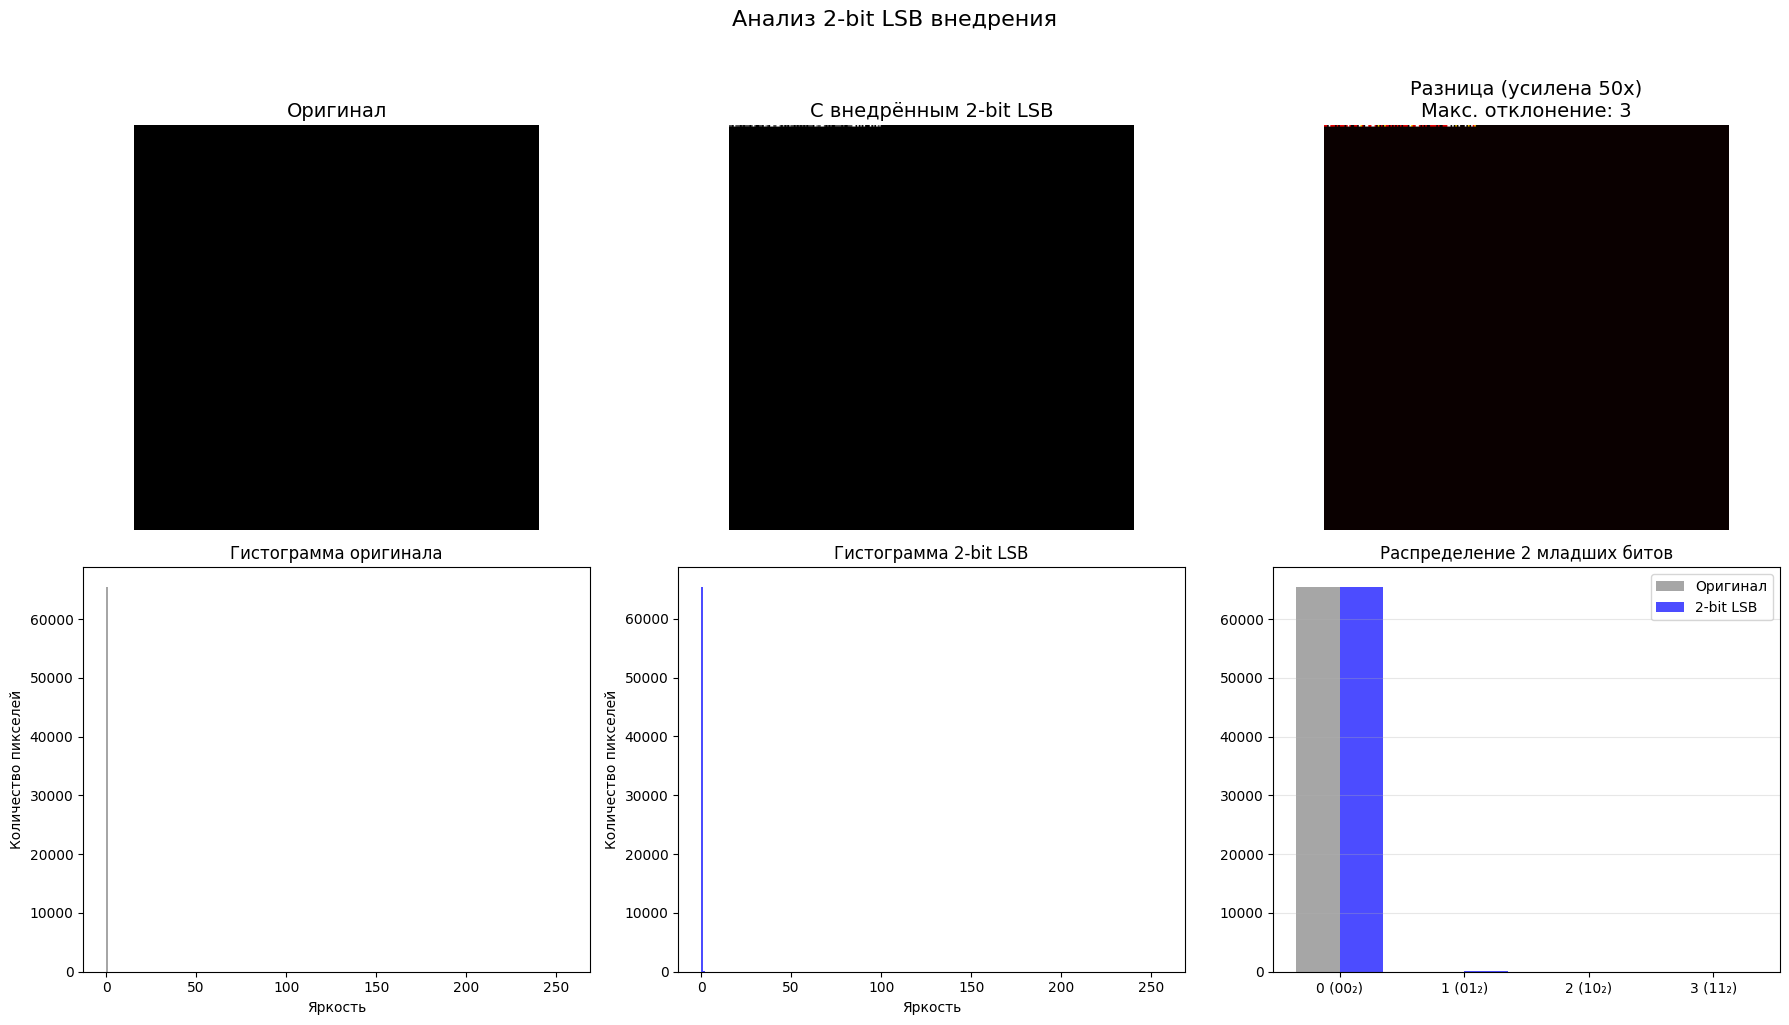


 СТАТИСТИКА ИЗМЕНЕНИЙ (2-bit LSB)
 Всего пикселей: 65,536
 Изменено пикселей: 64 (0.10%)
 Уникальные отклонения: [-3 -2 -1  0]
 Макс. отклонение: 3 (из возможных 3)

 Распределение 2 младших битов:
----------------------------------------
Значение     Оригинал        2-bit LSB       Изменение      
----------------------------------------
0 (00₂):     65,536          65,472          -64++++++++++++
1 (01₂):     0               41              41+++++++++++++
2 (10₂):     0               7               7++++++++++++++
3 (11₂):     0               16              16+++++++++++++
----------------------------------------

  Образец #64: gray_063.png

  Статистика изменений пикселей:
    Всего пикселей: 65,536
    Изменено пикселей: 96
    Процент изменений: 0.1465%
    Уникальные изменения: [0 1 2 3]
    Макс. отклонение: 3 (из 3 возможных)

  Проверка извлечения сообщения:
    Ожидаемая длина: 24
    Извлечённая длина: 24
    Совпадение:  ДА

  Образец #128: gray_127.png

  Статистика и

In [13]:
# Запуск полной проверки датасета (2-bit LSB)

results = full_dataset_verification_2bit(INPUT_DIR, OUTPUT_DIR, SECRET_MESSAGE, num_samples=5)